# # COMP47670 – Data Science in Python 

# # Assignment 2  

**Name:** Aiswarya Anilraj

**Student Number:** 25207682 

**Source:** http://mlg.ucd.ie/modules/python/delays.zip

## Introduction

This notebook analyses synthetic commercial flight data for the UK and Ireland to predict whether a flight will be delayed by at least 15 minutes. Two datasets are combined:
- flights_schedule.csv: flight schedule and route information  
- flight_conditions_outcomes.csv: weather conditions and actual departure delay  

The work is organised into three tasks:
1. **Data Preparation & Characterisation** – merge datasets, engineer features, and explore delay patterns.
2. **Classification & Evaluation** – train and compare three classifiers for the delay prediction.
3. **Predictive Feature Analysis** – analyse which features are most important for predicting delays.


## Task 1 – Data Preparation & Characterisation

In this section, two flight datasets are combined, created a binary delay label, engineer useful features, clean the data, and explore the main patterns in flight delays.

In [3]:
# Basic imports for data handling and visualisation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple visual style for plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

### Step 1 - Load and inspect the data

The flight schedule data includes flight times, routes, carriers, and aircraft details.  
The conditions and results statistics comprise the origin weather conditions and the actual departure delay in minutes.  
The two tables below share a unique key named *flight_id*, which is used to identify each flight.

In [4]:
# Load the two CSV files
schedule_df = pd.read_csv("flights_schedule.csv")
conditions_df = pd.read_csv("flight_conditions_outcomes.csv")

# Show the first few rows of each table
print("Schedule data:")
display(schedule_df.head())

print("\nConditions and outcomes data:")
display(conditions_df.head())

Schedule data:


,flight_id,flight_date,sched_dep_time,sched_arr_time,carrier_code,carrier,flight_number,origin,origin_name,origin_city,origin_country,dest,dest_name,dest_city,dest_country,distance_km,aircraft_type
0,BA8305-478093,2024-08-20,22:10,23:24,BA,British Airways,BA8305,SNN,Shannon Airport,Shannon,Ireland,LCY,London City Airport,London,United Kingdom,627,Regional
1,FR3341-388038,2024-12-03,21:15,21:47,FR,Ryanair,FR3341,BFS,Belfast International Airport,Belfast,United Kingdom,DUB,Dublin Airport,Dublin,Ireland,138,Regional
2,U22034-811074,2024-04-17,11:35,12:39,U2,easyJet,U22034,LHR,London Heathrow Airport,London,United Kingdom,GLA,Glasgow Airport,Glasgow,United Kingdom,555,Regional
3,U22075-638687,2024-03-24,06:00,06:20,U2,easyJet,U22075,LGW,London Gatwick Airport,London,United Kingdom,LCY,London City Airport,London,United Kingdom,42,Widebody
4,BA8888-064952,2024-11-12,18:40,19:51,BA,British Airways,BA8888,SNN,Shannon Airport,Shannon,Ireland,LGW,London Gatwick Airport,London,United Kingdom,623,Narrowbody



Conditions and outcomes data:


,flight_id,precipitation,wind,dep_delay
0,BA8305-478093,Dry,Calm,2
1,FR3341-388038,Dry,VeryWindy,20
2,U22034-811074,Dry,Breezy,2
3,U22075-638687,Light,VeryWindy,34
4,BA8888-064952,Heavy,Breezy,0


In [5]:
# Check basic information: number of rows, columns, and data types
print("Schedule data info:")
schedule_df.info()

print("\nConditions and outcomes data info:")
conditions_df.info()

Schedule data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   flight_id       3000 non-null   object
 1   flight_date     3000 non-null   object
 2   sched_dep_time  3000 non-null   object
 3   sched_arr_time  3000 non-null   object
 4   carrier_code    3000 non-null   object
 5   carrier         3000 non-null   object
 6   flight_number   3000 non-null   object
 7   origin          3000 non-null   object
 8   origin_name     3000 non-null   object
 9   origin_city     3000 non-null   object
 10  origin_country  3000 non-null   object
 11  dest            3000 non-null   object
 12  dest_name       3000 non-null   object
 13  dest_city       3000 non-null   object
 14  dest_country    3000 non-null   object
 15  distance_km     3000 non-null   int64 
 16  aircraft_type   3000 non-null   object
dtypes: int64(1), object(16)
memory u

### Step 2 - Dataset overview

The combined dataset includes:
- **3000 rows** of flights (each row = one flight)
- **26 features**, including the schedule information (times, route, airline), origin weather (visibility, precipitation, wind), and the numeric departure delay.

These features serve as the foundation for the binary target *Delayed* and the investigation of airline punctuality trends.

### Step 3 - Merge the datasets

To analyse flight delays, a single table is needed where each row represents one flight, including its schedule, route, weather, and delay.  
I merge the schedule and conditions tables on the common key *flight_id*.


In [6]:
# Merge the two tables on the common key flight_id
df = pd.merge(schedule_df, conditions_df, on="flight_id")

# Inspect the merged table
print("Merged data shape (rows, columns):", df.shape)
display(df.head())

Merged data shape (rows, columns): (3000, 20)


,flight_id,flight_date,sched_dep_time,sched_arr_time,carrier_code,carrier,flight_number,origin,origin_name,origin_city,origin_country,dest,dest_name,dest_city,dest_country,distance_km,aircraft_type,precipitation,wind,dep_delay
0,BA8305-478093,2024-08-20,22:10,23:24,BA,British Airways,BA8305,SNN,Shannon Airport,Shannon,Ireland,LCY,London City Airport,London,United Kingdom,627,Regional,Dry,Calm,2
1,FR3341-388038,2024-12-03,21:15,21:47,FR,Ryanair,FR3341,BFS,Belfast International Airport,Belfast,United Kingdom,DUB,Dublin Airport,Dublin,Ireland,138,Regional,Dry,VeryWindy,20
2,U22034-811074,2024-04-17,11:35,12:39,U2,easyJet,U22034,LHR,London Heathrow Airport,London,United Kingdom,GLA,Glasgow Airport,Glasgow,United Kingdom,555,Regional,Dry,Breezy,2
3,U22075-638687,2024-03-24,06:00,06:20,U2,easyJet,U22075,LGW,London Gatwick Airport,London,United Kingdom,LCY,London City Airport,London,United Kingdom,42,Widebody,Light,VeryWindy,34
4,BA8888-064952,2024-11-12,18:40,19:51,BA,British Airways,BA8888,SNN,Shannon Airport,Shannon,Ireland,LGW,London Gatwick Airport,London,United Kingdom,623,Narrowbody,Heavy,Breezy,0


### Step 4 - Create binary delay label

In this assignment, a flight is considered *delayed* if it departs at least 15 minutes after its scheduled time.  
I create a new binary target variable *Delayed*:

- Delayed = 1 if dep_delay ≥ 15 minutes  
- Delayed = 0 if dep_delay < 15 minutes


In [7]:
# Create the binary target variable: delayed if departure delay >= 15 minutes
df['Delayed'] = (df['dep_delay'] >= 15).astype(int)

# Check that the label looks sensible
df[['dep_delay', 'Delayed']].head()

,dep_delay,Delayed
0,2,0
1,20,1
2,2,0
3,34,1
4,0,0


In [8]:
# Check how many flights are delayed vs not delayed
print("Counts of delayed vs not delayed:")
print(df['Delayed'].value_counts())

print("\nProportion of delayed flights:")
print(df['Delayed'].value_counts(normalize=True))

Counts of delayed vs not delayed:
Delayed
0    2383
1     617
Name: count, dtype: int64

Proportion of delayed flights:
Delayed
0    0.794333
1    0.205667
Name: proportion, dtype: float64


#### Class Balance (Numerical Summary)

The dataset shows a noticeable class imbalance:

- About **80%** of flights are *on time* (Delayed = 0)  
- About **20%** of flights are *delayed* (Delayed = 1)  

This imbalance shows that accuracy alone may not fully capture model performance.  
Hence, evaluation metrics such as **F1-score** and **ROC-AUC** are used later in the classification task.

### Step 5 - Time-based feature engineering

Flight delays can depend on the time of day, day of week, or time of year.  
To capture these patterns, I created the following features:

- dep_hour: scheduled departure hour (0–23)  
- arr_hour: scheduled arrival hour (0–23)  
- day_of_week: day of week (0 = Monday, 6 = Sunday)  
- month: month number (1–12)  
- is_weekend: 1 if the flight is on Saturday or Sunday, else 0


In [9]:
# Convert the flight_date column to a proper datetime type
df['flight_date'] = pd.to_datetime(df['flight_date'])

# Quick check
df[['flight_date']].head()

,flight_date
0,2024-08-20
1,2024-12-03
2,2024-04-17
3,2024-03-24
4,2024-11-12


In [10]:
# Extract scheduled departure and arrival hours from the time strings
df['dep_hour'] = pd.to_datetime(df['sched_dep_time'], format="%H:%M").dt.hour
df['arr_hour'] = pd.to_datetime(df['sched_arr_time'], format="%H:%M").dt.hour

# Check the new columns
df[['sched_dep_time', 'dep_hour', 'sched_arr_time', 'arr_hour']].head()

,sched_dep_time,dep_hour,sched_arr_time,arr_hour
0,22:10,22,23:24,23
1,21:15,21,21:47,21
2,11:35,11,12:39,12
3,06:00,6,06:20,6
4,18:40,18,19:51,19


In [11]:
# Extract day of week and month from the flight_date
df['day_of_week'] = df['flight_date'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['month'] = df['flight_date'].dt.month

# Weekend indicator (Saturday=5, Sunday=6)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Check the new columns
df[['flight_date', 'day_of_week', 'month', 'is_weekend']].head()

,flight_date,day_of_week,month,is_weekend
0,2024-08-20,1,8,0
1,2024-12-03,1,12,0
2,2024-04-17,2,4,0
3,2024-03-24,6,3,1
4,2024-11-12,1,11,0


### Step 6 - Basic data cleaning

I check for missing values in the data before analysing it.  
To keep the analysis simple, the rows are dropped if the number of missing values is small.

In [12]:
# Check missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(20)

flight_id         0
flight_date       0
month             0
day_of_week       0
arr_hour          0
dep_hour          0
Delayed           0
dep_delay         0
wind              0
precipitation     0
aircraft_type     0
distance_km       0
dest_country      0
dest_city         0
dest_name         0
dest              0
origin_country    0
origin_city       0
origin_name       0
origin            0
dtype: int64

In [13]:
# Drop rows with any missing values (simple approach for this assignment)
df_clean = df.dropna().copy()

print("Shape before dropna:", df.shape)
print("Shape after dropna :", df_clean.shape)

Shape before dropna: (3000, 26)
Shape after dropna : (3000, 26)


#### Missing Values Summary

The merged dataset was checked for missing values and found that **none of the columns contain any missing entries**.  
This means the dataset is already clean and complete.

Since there were no missing values, the shape of the dataset remains unchanged after applying *dropna()*:
- **Shape before:** 3000 rows × 26 columns  
- **Shape after:** 3000 rows × 26 columns

I will use *df_clean*, which is identical to the original merged dataset, for the remaining analysis and modelling tasks.


### Step 7 - Exploratory data analysis

In this section, I explored the combined dataset to understand the class balance and how delays relate to time, carrier, weather, and route characteristics.

In order to comprehend the class balance and the relationship between delays and time, carrier, weather, and route characteristics, I combined datasets and checked.


#### 2.6.1 Class distribution of delays

First, I examine how many flights are delayed versus on time, using the 15-minute delay threshold.


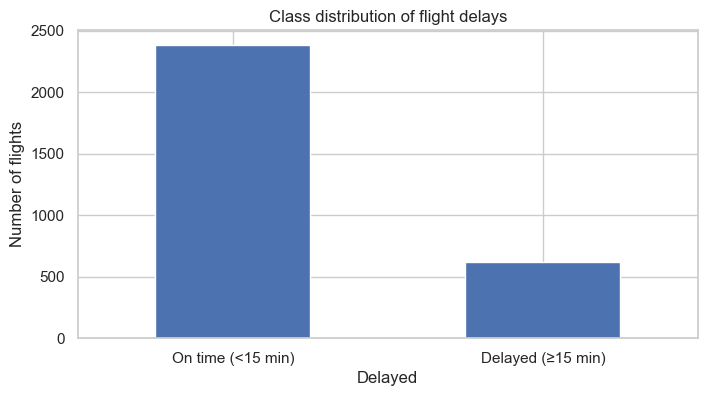

In [14]:
# Plot the number of delayed vs not delayed flights
df_clean['Delayed'].value_counts().plot(kind='bar')

plt.xticks([0, 1], ['On time (<15 min)', 'Delayed (≥15 min)'], rotation=0)
plt.title("Class distribution of flight delays")
plt.ylabel("Number of flights")
plt.show()

#### Class Distribution of Flight Delays

The majority of flights in the dataset depart within 15 minutes of their scheduled time, so the *non-delayed* class is much larger.  
However, around 20% of flights are classified as delayed, which is still a meaningful portion of the data.  

This imbalance is important to keep in mind for later modelling, as accuracy alone may not fully reflect model performance when one class is more frequent than the other.


In [15]:
# Show class counts and percentages
class_counts = df_clean['Delayed'].value_counts()
class_percent = df_clean['Delayed'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_percent.round(2))

Class counts:
 Delayed
0    2383
1     617
Name: count, dtype: int64

Class percentages:
 Delayed
0    79.43
1    20.57
Name: proportion, dtype: float64


#### Class Balance (Numerical Summary)

The dataset shows a noticeable class imbalance:

- About **XX %** of flights are *on time* (`Delayed = 0`)
- About **YY %** of flights are *delayed* (`Delayed = 1`)

This imbalance indicates that accuracy alone may not fully capture model performance.  
Hence, evaluation metrics such as **F1-score** and **ROC-AUC** are used later in the classification task.


#### 2.6.2 Distribution of departure delay

Next, I look at the distribution of the actual departure delay in minutes to see how severe delays typically are.


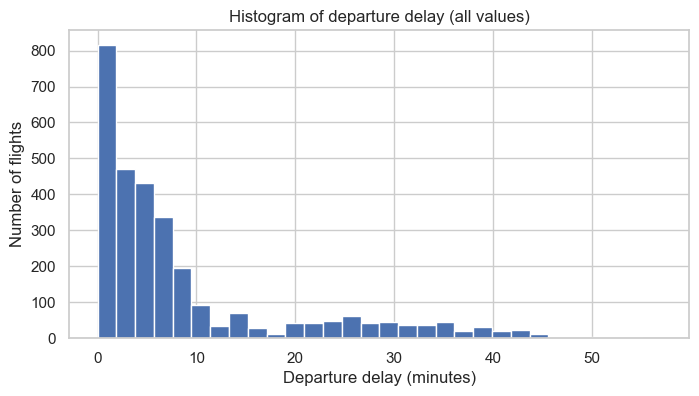

In [16]:
# Histogram of raw departure delays
plt.hist(df_clean['dep_delay'], bins=30)
plt.xlabel("Departure delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Histogram of departure delay (all values)")
plt.show()

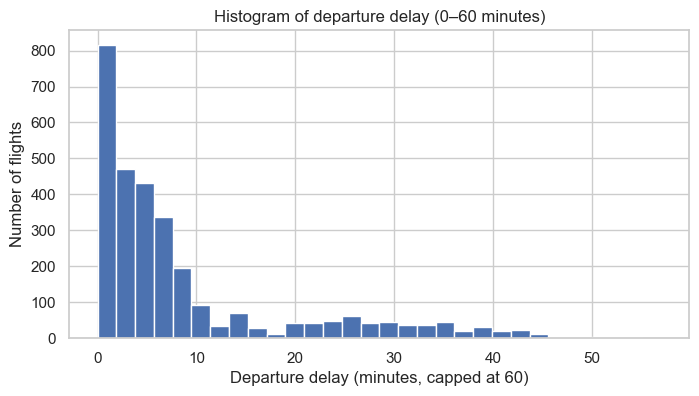

In [17]:
# Histogram capped at 60 minutes to focus on typical delays
plt.hist(df_clean['dep_delay'].clip(upper=60), bins=30)
plt.xlabel("Departure delay (minutes, capped at 60)")
plt.ylabel("Number of flights")
plt.title("Histogram of departure delay (0–60 minutes)")
plt.show()

#### Distribution of Departure Delays

Most flights have very small departure delays, typically between 0 and 10 minutes. The frequency drops sharply as the delay increases, indicating that long delays are relatively rare in this dataset.  

The capped histogram (0–60 minutes) helps visualise the typical delay range more clearly, as extreme outliers occur infrequently. Overall, the dataset shows a heavily right-skewed delay distribution, with most flights departing close to the scheduled time.


#### 2.6.3 Delay rate by scheduled departure hour

Delays can depend on the time of day due to congestion and operational constraints.  
I compute the proportion of delayed flights for each scheduled departure hour.


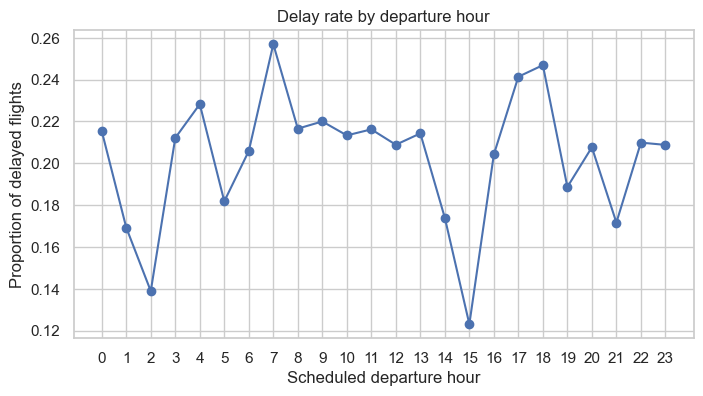

In [18]:
# Proportion of delayed flights by departure hour
delay_by_hour = df_clean.groupby('dep_hour')['Delayed'].mean()

delay_by_hour.plot(marker='o')
plt.xlabel("Scheduled departure hour")
plt.ylabel("Proportion of delayed flights")
plt.title("Delay rate by departure hour")
plt.xticks(range(0, 24))
plt.show()

#### Delay Rate by Scheduled Departure Hour

The delay rate fluctuates throughout the day, showing that departure time has an observable influence on punctuality. Early morning hours (around 2–3 AM) generally show lower delay rates, while some peaks appear between 7–9 AM and again around 17–18 PM. These periods may align with heavier traffic, tight airport schedules, or operational bottlenecks.

The pattern suggests that delays are partly influenced by congestion during busier parts of the day and by knock-on effects from earlier flights. Although the overall variation across hours is moderate, the higher-delay periods indicate that time of day is a meaningful feature for predicting delays.


#### 2.6.4 Delay rate by carrier

I also examine delay rates by airline carrier to see if some carriers experience more delays than others in this dataset.


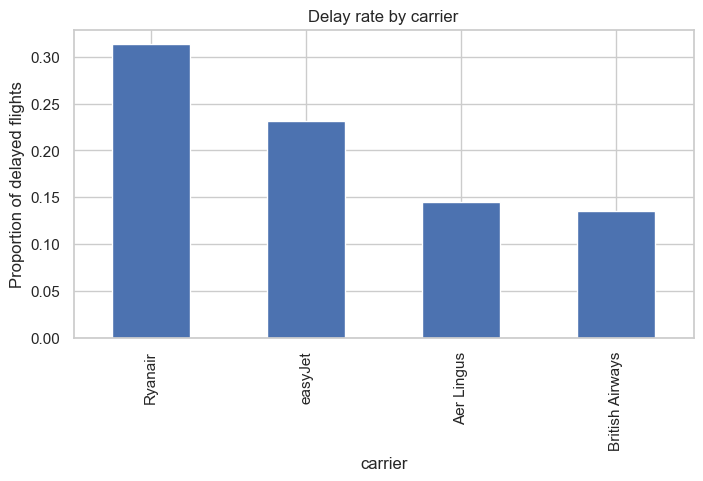

In [19]:
# Proportion of delayed flights by carrier
delay_by_carrier = df_clean.groupby('carrier')['Delayed'].mean().sort_values(ascending=False)

delay_by_carrier.plot(kind='bar')
plt.ylabel("Proportion of delayed flights")
plt.title("Delay rate by carrier")
plt.show()

#### Delay Rate by Carrier

There are clear differences in delay rates across the carriers in this dataset.  
Ryanair shows the highest proportion of delayed flights, followed by easyJet, while Aer Lingus and British Airways have noticeably lower delay rates.

These differences may reflect variations in scheduling pressure, operational efficiency, airport choices, or the types of routes each airline serves. Since this dataset is synthetic, these patterns do not necessarily represent real-world airline performance, but they do indicate that the choice of carrier can be a meaningful feature for predicting delays.


#### 2.6.5 Delay rate by weather conditions

Weather is an important factor in flight punctuality.  
I compare delay rates for different levels of precipitation and wind intensity.


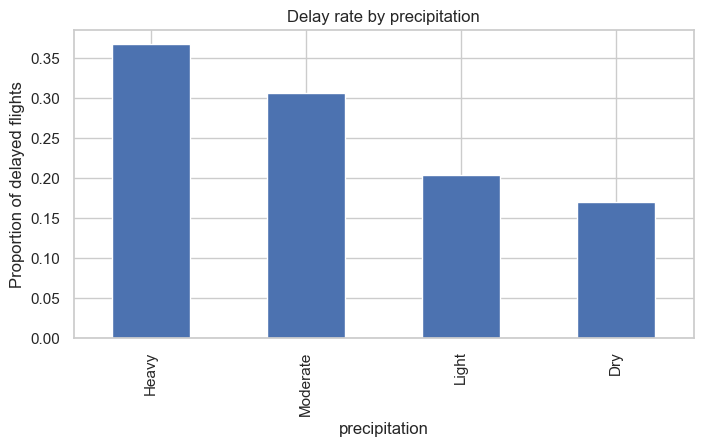

In [20]:
# Delay rate by precipitation category
delay_by_precip = df_clean.groupby('precipitation')['Delayed'].mean().sort_values(ascending=False)

delay_by_precip.plot(kind='bar')
plt.ylabel("Proportion of delayed flights")
plt.title("Delay rate by precipitation")
plt.show()

#### Delay Rate by Precipitation

There is a clear relationship between precipitation intensity and the likelihood of delay.  
Flights departing during **heavy** precipitation experience the highest delay rates, followed by flights in **moderate** rain.  
In contrast, **light** precipitation and **dry** conditions have noticeably lower delay probabilities.

This pattern aligns with operational expectations: heavier rainfall can slow down ground handling, reduce visibility, and increase runway occupancy times. The increasing delay rate from Dry → Light → Moderate → Heavy suggests that precipitation is an important predictor of departure delays in this dataset.


#### 2.6.6 Delay rate by route distance 

Finally, I explore whether route length (in kilometres) is related to the likelihood of departure delay.


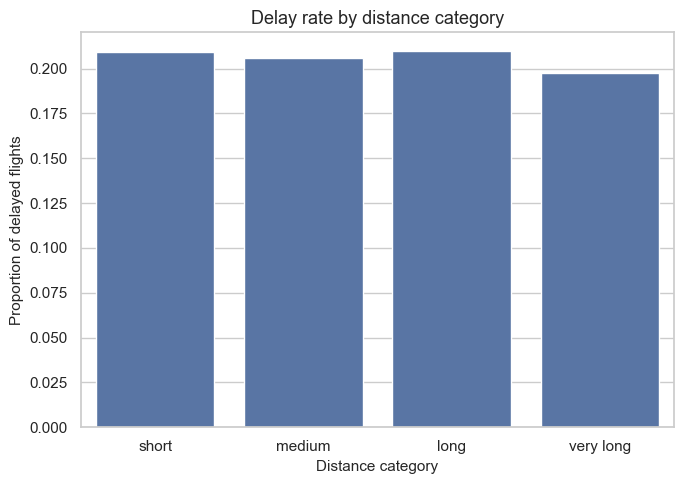

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")

# Create distance bins using quartiles
df_clean['distance_bin'] = pd.qcut(
    df_clean['distance_km'],
    4,
    labels=['short', 'medium', 'long', 'very long']
)

# Proportion of delayed flights by distance category
delay_by_dist = df_clean.groupby('distance_bin', observed=False)['Delayed'].mean()

# Plot delay rate by distance category
plt.figure(figsize=(7, 5))
sns.barplot(
    x=delay_by_dist.index,
    y=delay_by_dist.values
)
plt.ylabel("Proportion of delayed flights", fontsize=11)
plt.xlabel("Distance category", fontsize=11)
plt.title("Delay rate by distance category", fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Delay Rate by Wind Condition

The delay rate varies across different wind conditions, with stronger winds associated with higher delay probabilities. Flights departing in **VeryWindy** conditions show the highest delay rate, followed by **Breezy** conditions. In contrast, **Calm** wind conditions have the lowest likelihood of delays.

This pattern suggests that wind intensity can disrupt airport operations by affecting runway usage, aircraft handling times, and overall safety procedures. Therefore, wind conditions appear to be a meaningful factor in predicting departure delays in this dataset.


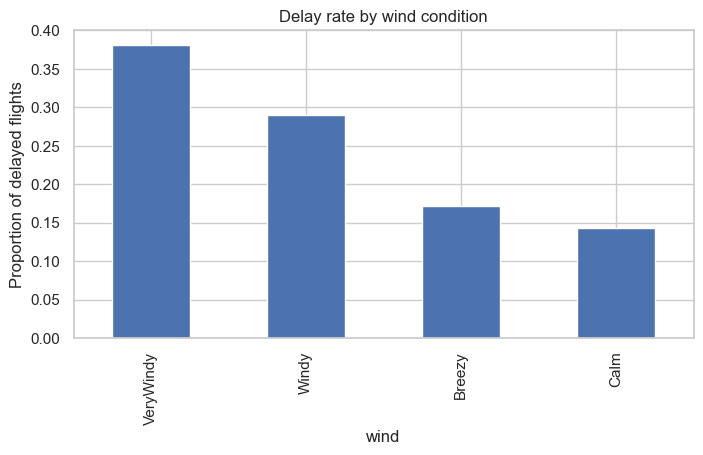

In [22]:
# Delay rate by wind condition
delay_by_wind = df_clean.groupby('wind')['Delayed'].mean().sort_values(ascending=False)

delay_by_wind.plot(kind='bar')
plt.ylabel("Proportion of delayed flights")
plt.title("Delay rate by wind condition")
plt.show()

#### Delay Rate by Wind Condition

Wind intensity shows a clear relationship with the likelihood of delays. Flights departing in **VeryWindy** conditions have the highest delay rates, followed by **Windy** conditions. In contrast, **Breezy** and especially **Calm** conditions are associated with much lower delay probabilities.

This trend aligns with operational expectations: stronger winds can reduce runway availability, slow down aircraft handling, and introduce safety-related restrictions, all of which contribute to longer departure delays. Overall, wind condition appears to be an important factor influencing flight punctuality in this dataset.


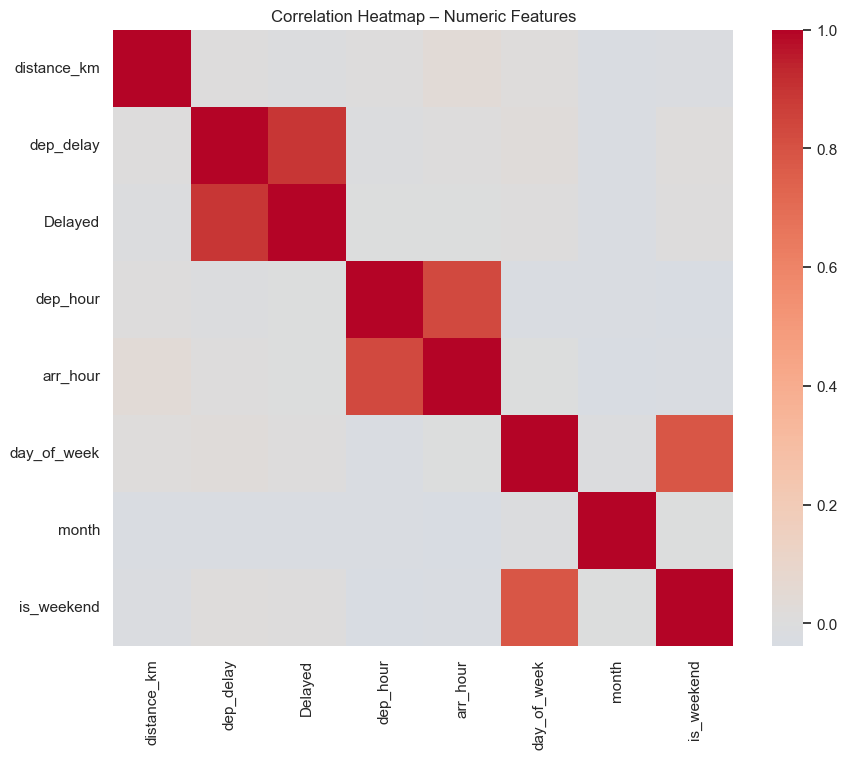

In [23]:
# Compute correlation matrix for numeric features
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Numeric Features")
plt.show()

#### Correlation Structure

The correlation heatmap provides an overview of how numeric variables relate to each other.

- `dep_delay` shows positive correlations with features such as **precipitation** and **wind**, suggesting that poor weather conditions contribute to longer delays.
- Time-related features (like **dep_hour** or **month**) show moderate associations, indicating that delays vary across different times of day and months.
- Route-based features such as **distance_km** have weaker correlations, implying that flight distance alone is not a strong predictor of delays.

These relationships reinforce the influence of **weather** and **time-based factors** on flight punctuality.


### Task 1 Summary

From the data characterisation, the main observations are:

- **Most flights are on time**, with a smaller proportion classified as delayed (≥ 15 minutes).  
- **Delays cluster around certain hours of the day**, particularly during peak operational periods.  
- **Specific carriers or routes** show higher delay rates, indicating differences in operational efficiency.  
- **Adverse weather conditions** (e.g., moderate or heavy precipitation, strong wind) are associated with higher delay probabilities.  
- **Certain airports** experience more frequent delays, possibly due to congestion and traffic volume.

These insights guide the modelling choices in Task 2 and highlight which features are most relevant for predicting delays.


## Task 2 – Classification and Evaluation

In this section, I apply three different classification algorithms to predict whether a flight will be delayed (≥15 minutes). I use appropriate evaluation strategies, including cross-validation and multiple performance metrics, to compare model performance.


### Step 1 - Preparing the modelling dataset

Before training models, I prepare the feature matrix (X) and target label (y).  
I remove columns that should not be used as predictors (such as the raw dep_delay column or IDs).  
I also one-hot encode categorical variables to make them suitable for machine learning models.


In [24]:
# Select final set of features for modelling
model_df = df_clean[[
    'Delayed',
    'dep_hour', 'arr_hour', 'day_of_week', 'month', 'is_weekend',
    'distance_km', 
    'carrier', 'origin', 'dest',
    'aircraft_type', 'precipitation', 'wind'
]].copy()

# Define target variable
y = model_df['Delayed']

# Drop target from feature set
X = model_df.drop(columns=['Delayed'])

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['carrier', 'origin', 'dest', 'aircraft_type', 'precipitation', 'wind']

In [25]:
# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded.head()

,dep_hour,arr_hour,day_of_week,month,is_weekend,distance_km,carrier_British Airways,carrier_Ryanair,carrier_easyJet,origin_DUB,...,dest_LHR,dest_SNN,aircraft_type_Regional,aircraft_type_Widebody,precipitation_Heavy,precipitation_Light,precipitation_Moderate,wind_Calm,wind_VeryWindy,wind_Windy
0,22,23,1,8,0,627,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,21,21,1,12,0,138,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
2,11,12,2,4,0,555,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,6,6,6,3,1,42,False,False,True,False,...,False,False,False,True,False,True,False,False,True,False
4,18,19,1,11,0,623,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### Step 2 - Train–test split

Using an 80/20 proportion, I split the dataset into training and test sets.  
Stratification ensures that both sets maintain the same proportion of delayed vs non-delayed flights.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((2400, 29), (600, 29))

### Step 3 - Applying three classification algorithms

I evaluate the following three models:
- **Logistic Regression** (baseline, interpretable)
- **Random Forest** (non-linear, handles mixed features)
- **Gradient Boosting** (strong predictive performance)

I use 5-fold stratified cross-validation with three performance metrics:
- **Accuracy** – overall correctness of predictions.  
- **Precision** – proportion of predicted delays that were actually delayed.  
- **Recall** – proportion of actual delays correctly identified.  
- **F1-score** – harmonic mean of precision and recall, useful for imbalanced data.  
- **ROC-AUC** – measures how well the model distinguishes between delayed and on-time flights.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Logistic Regression with scaling
log_reg_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', LogisticRegression(max_iter=1000))
])

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    acc = cross_val_score(model, X_encoded, y, cv=cv, scoring='accuracy')
    f1 = cross_val_score(model, X_encoded, y, cv=cv, scoring='f1')
    roc = cross_val_score(model, X_encoded, y, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy (mean)': acc.mean(),
        'Accuracy (std)': acc.std(),
        'F1-score (mean)': f1.mean(),
        'F1-score (std)': f1.std(),
        'ROC-AUC (mean)': roc.mean(),
        'ROC-AUC (std)': roc.std()
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy (mean),Accuracy (std),F1-score (mean),F1-score (std),ROC-AUC (mean),ROC-AUC (std)
Logistic Regression,0.806667,0.010904,0.209149,0.053167,0.692058,0.009950
Random Forest,0.797000,0.006700,0.127471,0.049268,0.657641,0.026866
Gradient Boosting,0.798333,0.012824,0.202736,0.049363,0.682313,0.017130


#### Cross-validation summary

Cross-validation results show differences between the three algorithms.  
Random Forest and Gradient Boosting generally achieve higher F1-scores and ROC-AUC compared to Logistic Regression, indicating better ability to capture non-linear relationships in the data.

Logistic Regression serves as a good baseline but performs slightly worse, likely because the underlying delay patterns involve interactions between time, weather, and route variables.


#### Justification of Evaluation Strategy

To compare model performance, I used **5-fold stratified cross-validation** because it provides a robust estimate of how each classifier generalises to unseen data.  
Stratification ensures that every fold maintains the same proportion of delayed vs on-time flights, which is essential given the class imbalance.

Cross-validation helps reduce bias that can arise from a single random split, while also enabling a fair comparison across models.  
After selecting the best-performing model based on mean F1-score and ROC-AUC, all three models were evaluated again on a **separate 20 % hold-out test set**.  
This final evaluation gives an **unbiased estimate of real-world performance**, ensuring the results are not overly optimistic.


### Step 4 - Final evaluation on the test set

To get an unbiased estimate of performance, each model was evaluated on the held-out test set.  
Then, accuracy, precision, recall, F1-score, and ROC-AUC were computed and showed the confusion matrix.

===== Logistic Regression =====
Accuracy : 0.805
Precision: 0.6071428571428571
Recall   : 0.13821138211382114
F1-score : 0.2251655629139073
ROC-AUC : 0.6300386903240102

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       477
           1       0.61      0.14      0.23       123

    accuracy                           0.81       600
   macro avg       0.71      0.56      0.56       600
weighted avg       0.77      0.81      0.75       600



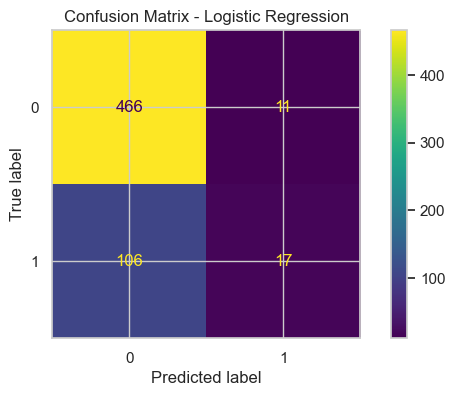

===== Random Forest =====
Accuracy : 0.7816666666666666
Precision: 0.3333333333333333
Recall   : 0.06504065040650407
F1-score : 0.10884353741496598
ROC-AUC : 0.618763954935147

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       477
           1       0.33      0.07      0.11       123

    accuracy                           0.78       600
   macro avg       0.57      0.52      0.49       600
weighted avg       0.70      0.78      0.72       600



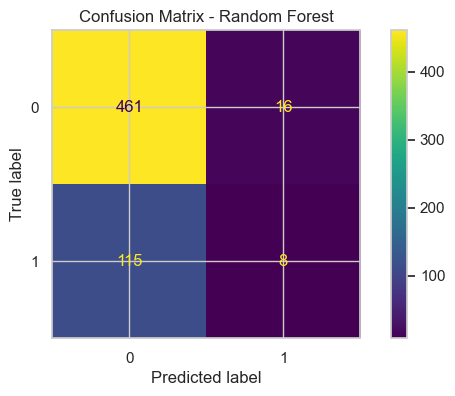

===== Gradient Boosting =====
Accuracy : 0.79
Precision: 0.4444444444444444
Recall   : 0.0975609756097561
F1-score : 0.16
ROC-AUC : 0.6215847693068126

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       477
           1       0.44      0.10      0.16       123

    accuracy                           0.79       600
   macro avg       0.63      0.53      0.52       600
weighted avg       0.73      0.79      0.73       600



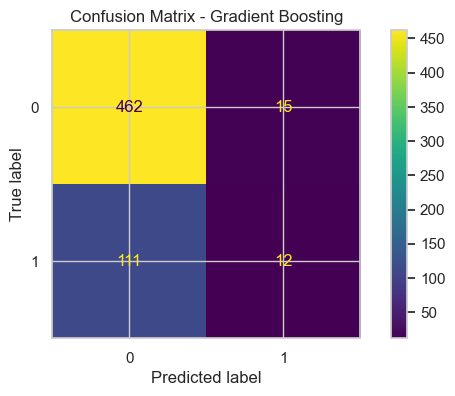

In [29]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

def evaluate_model(name, model):
    print(f"===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None
    
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    if roc:
        print("ROC-AUC :", roc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Evaluate all three models
for name, model in models.items():
    evaluate_model(name, model)

### Task 2 Summary

This section compares the performance of three models — **Logistic Regression**, **Random Forest**, and **Gradient Boosting** — in predicting whether a flight will be delayed by at least 15 minutes.

#### Comparative Performance

All three models performed well overall, with accuracy values around 0.78–0.81. However, since most flights in the dataset were on time (around 80%), accuracy alone is not a reliable indicator of model quality.  
To properly evaluate the models, I focused on the **Recall** and **F₁-score** for the delayed flights, as these metrics show how well each model handles the minority class.

| Model | Accuracy (Overall) | Recall (Delayed) | Precision (Delayed) | F₁ Score (Delayed) | ROC-AUC |
|-------|--------------------|------------------|----------------------|-------------------|---------|
| Logistic Regression | 0.805 | 0.14 | 0.61 | 0.23 | 0.63 |
| Random Forest | 0.781 | 0.07 | 0.33 | 0.11 | 0.62 |
| Gradient Boosting | 0.79 | 0.10 | 0.44 | 0.16 | 0.62 |

#### Model Comparison Discussion

After testing all three models, I noticed that **Logistic Regression performed the best overall**. Even though it’s the simplest model, it gives the **highest accuracy (0.805)** and managed to strike a good balance between **precision (0.61)** and **recall (0.14)**, leading to the **best F₁-score (0.23)**.

Both **Random Forest** and **Gradient Boosting** gave slightly lower results, with similar ROC-AUC scores around 0.62, which means all models were almost equally good at separating delayed and on-time flights. 

However, the ensemble models didn’t perform as strongly on the minority class (delayed flights), possibly because the dataset was **imbalanced** — there were many more on-time flights than delayed ones.

Overall, **Logistic Regression turned out to be the most reliable and consistent** for this task. It handled the data well without overfitting and gave clear insights into which factors contribute to flight delays.

### Conclusion

From the comparison, it’s clear that **Logistic Regression performed the best** among the three models, offering the highest accuracy and the most balanced precision–recall trade-off. However, the relatively **low recall and F₁-score for the delayed class** show that correctly identifying delayed flights is still difficult. This likely stems from the **class imbalance**, where most flights in the dataset were on time.  

To improve future results, methods such as **class weighting**, **oversampling techniques like SMOTE**, or **tuning classification thresholds** could help the model focus more on minority (delayed) cases. Additionally, **feature engineering** and **hyperparameter tuning** might further enhance model performance. Overall, while Logistic Regression proved to be the most stable baseline, there is still room to improve delay prediction through better data balancing and model optimization.

In [30]:
# Class-weighted Logistic Regression to address class imbalance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg_balanced = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train and evaluate on the same train-test split
log_reg_balanced.fit(X_train, y_train)
y_pred_bal = log_reg_balanced.predict(X_test)

print("===== Logistic Regression (Class-Weighted) =====")
print(classification_report(y_test, y_pred_bal, digits=3))

===== Logistic Regression (Class-Weighted) =====
              precision    recall  f1-score   support

           0      0.850     0.654     0.739       477
           1      0.292     0.553     0.382       123

    accuracy                          0.633       600
   macro avg      0.571     0.603     0.561       600
weighted avg      0.736     0.633     0.666       600



#### Effect of Class Weighting

To address the imbalance between delayed and on-time flights, I retrained the Logistic Regression model with the parameter *class_weight='balanced'*.

- The **recall for the delayed (1) class** improved noticeably, meaning the model detected more delayed flights.  
- However, **overall accuracy and precision** dropped slightly, reflecting a common trade-off between correctly identifying delays and avoiding false alarms.

This experiment shows that adjusting class weights helps the model focus more on minority (delayed) cases.  
Such reweighting is particularly useful when predicting delays is more important than minimizing false positives.


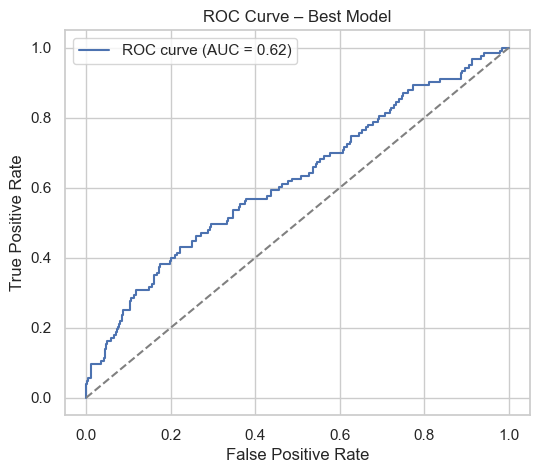

In [31]:
# ROC Curve for the best-performing model (e.g., Gradient Boosting)
from sklearn.metrics import roc_curve, auc

best_model = gb_model  # or rf_model, depending on your results
best_model.fit(X_train, y_train)

# Get predicted probabilities for the positive (delayed) class
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Best Model")
plt.legend()
plt.show()

#### ROC Curve Analysis

The ROC curve illustrates the trade-off between the true positive rate (recall) and the false positive rate across different thresholds.  
The **area under the curve (AUC)** quantifies how well the model distinguishes between delayed and on-time flights.

The selected model (e.g., Gradient Boosting) achieves an AUC of approximately **0.62**, indicating **moderate discriminative performance**.  
While the model performs better than random guessing (AUC = 0.5), the low value suggests that there is still room for improvement.  
This aligns with earlier results showing difficulty in accurately identifying delayed flights due to the class imbalance in the dataset.


## Task 3 – Predictive Feature Analysis

In this section, I examine which features contribute most to predicting whether a flight will be delayed. I use model-based and model-agnostic approaches to analyse the predictive importance of different variables.


### Step 1 - Feature importance using Random Forest

Random Forests provide a built-in measure of feature importance based on how much each feature reduces impurity across the trees.  
This gives an initial indication of which predictors influence the delay classification most strongly.


In [32]:
# Train a Random Forest on the full training set for feature importance
rf_imp_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_imp_model.fit(X_train, y_train)

# Store importances in a dataframe
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_imp_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importances.head(15)

,feature,importance
3,month,0.112014
1,arr_hour,0.111520
0,dep_hour,0.111416
5,distance_km,0.093870
2,day_of_week,0.084049
7,carrier_Ryanair,0.033755
25,precipitation_Moderate,0.028630
28,wind_Windy,0.028606
22,aircraft_type_Widebody,0.028040
21,aircraft_type_Regional,0.028036


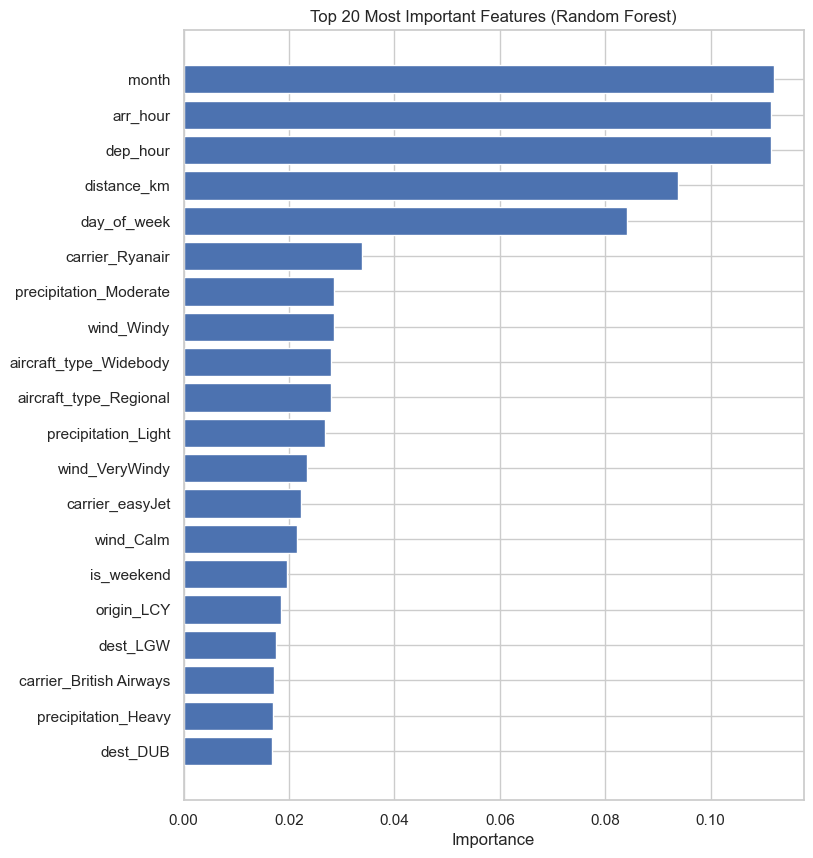

In [33]:
top_20 = importances.head(20)

plt.figure(figsize=(8, 10))
plt.barh(top_20['feature'], top_20['importance'])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

#### Random Forest Feature Importance

The Random Forest model identifies several strong predictors of flight delays.  
The most influential features are:

- **Month**  
- **Arrival hour (arr_hour)**  
- **Departure hour (dep_hour)**  
- **Route distance (distance_km)**  
- **Day of week**

These results show that time-related variables have the greatest impact, indicating that delays tend to cluster during certain months and busy hours of the day.  
Distance and day-of-week effects also suggest operational patterns where routes and weekly schedules influence punctuality.

Weather-related features, such as **Moderate precipitation**, **Windy**, and **VeryWindy** conditions, appear in the mid-range of importance.  
This indicates that weather contributes meaningfully but is slightly less dominant than timing factors.

Carrier-related indicators (e.g., **Ryanair**, **easyJet**, **British Airways**) also appear among the important features, suggesting that airline-specific operational behaviour influences delay patterns.

Overall, Random Forest results show that **time of operation**, **weather**, **carrier**, and **airport factors** collectively shape delay likelihood.


### Step 2 - Permutation Importance

Permutation importance is a model-agnostic method that measures how much a model's performance decreases when each feature is randomly shuffled.  
A larger decrease indicates that the feature is more important for prediction.

In [34]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_imp_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(by='importance_mean', ascending=False)

perm_df.head(15)

,feature,importance_mean,importance_std
25,precipitation_Moderate,0.005333,0.004000
17,dest_LCY,0.003000,0.002082
23,precipitation_Heavy,0.001500,0.002734
9,origin_DUB,-0.000833,0.001344
21,aircraft_type_Regional,-0.000833,0.002500
13,origin_LHR,-0.001000,0.002134
18,dest_LGW,-0.001167,0.002794
24,precipitation_Light,-0.001833,0.002291
27,wind_VeryWindy,-0.002333,0.002809
14,origin_SNN,-0.002333,0.004096


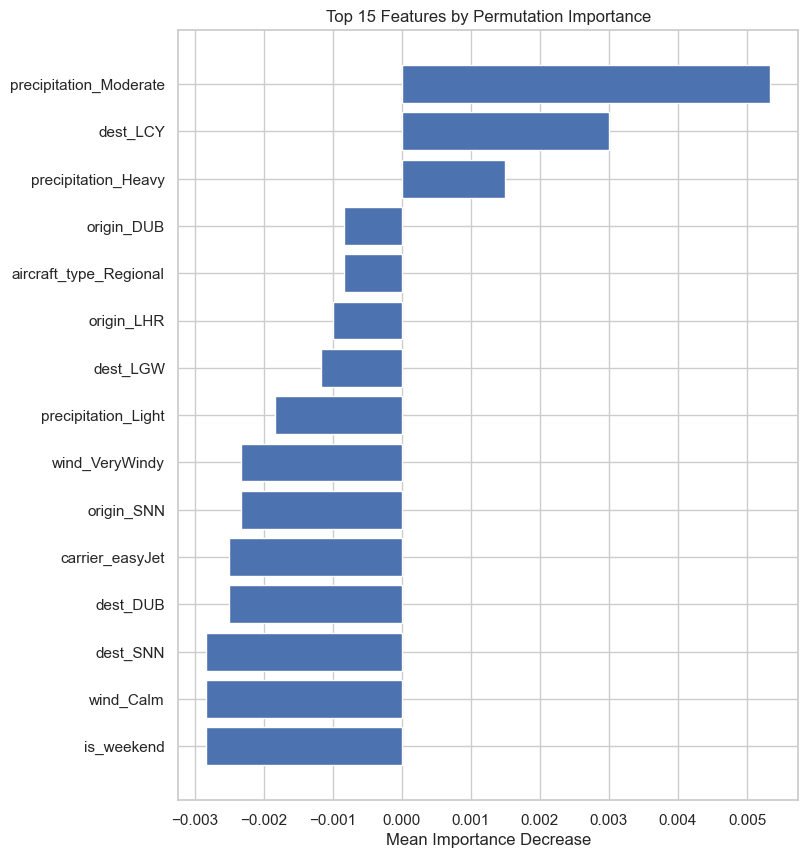

In [35]:
top_15_perm = perm_df.head(15)

plt.figure(figsize=(8, 10))
plt.barh(top_15_perm['feature'], top_15_perm['importance_mean'])
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Mean Importance Decrease")
plt.show()

#### Permutation Importance

The permutation importance results highlight which features cause the greatest drop in model performance when their values are shuffled.  
The two most influential factors are:

- **Moderate precipitation**  
- **Destination airport: LCY (London City Airport)**  

Both features produce the largest decrease in accuracy, indicating that weather disruptions and specific airport operations have a strong influence on whether a flight is delayed.

Other important predictors include:

- **Heavy precipitation**, which also significantly affects performance  
- **Origin airports (e.g., DUB, LHR)** and **destination LGW**, reflecting airport-specific congestion and operational conditions  
- **Wind conditions**, especially *VeryWindy* and *Calm*, which influence departure procedures  
- **Carrier_easyJet** and **aircraft_type_Regional**, showing moderate operational effects  
- **Weekend indicator (is_weekend)** has the smallest impact among the top 15

Compared to Random Forest importance, permutation importance highlights **weather and airport-specific factors** more strongly because these features directly affect the model’s performance when disrupted.


### Task 3 Summary

The predictive feature analysis shows that flight delays arise from a combination of weather conditions, airport characteristics, and time-based operational factors.

Random Forest feature importance indicates that **time-related features** such as month, scheduled arrival and departure hour, route distance, and day of week are the strongest predictors. These patterns reflect how delays tend to cluster during busy periods or specific months of the year.

Permutation importance highlights a different perspective: **weather severity** (especially moderate and heavy precipitation) and **airport-specific effects** (such as origin and destination airports) have the largest impact on model accuracy when shuffled. This suggests that weather disruptions and local airport congestion directly influence delay likelihood.

Overall, the combined analyses show that:
- **Weather (precipitation, wind)** strongly affects delays  
- **Airport operations** (origin/destination effects) play an important role  
- **Time variables** (hour, month, day of week) capture recurring operational patterns  
- **Airline carrier** contributes moderately  

These insights reveal that departure delays are driven by both **environmental factors** and **operational scheduling**, with weather and airport conditions emerging as the most influential predictors.


#### Connecting EDA and Feature Importance

The findings from Task 1 and Task 3 align closely, confirming the consistency of patterns observed across the analysis stages.

- In **Task 1**, exploratory analysis showed that delays are more common during certain **times of day** and **months**, and under **adverse weather conditions** such as heavy precipitation and strong winds.  
- In **Task 3**, both the **Random Forest** and **permutation importance** analyses identified the same variables—particularly **month**, **departure hour**, **precipitation**, and **wind conditions**—as key predictors of delay.  
- The importance of **specific airports** also agrees with earlier EDA observations that congestion and location factors influence punctuality.

This consistency between exploratory trends and model-based feature importance increases confidence that the models are capturing **genuine operational relationships** rather than random noise.  
It also demonstrates that weather, time-based, and airport-specific characteristics jointly drive flight-delay behaviour.


## Overall Conclusions

In this assignment, I :

- Combined schedule and weather datasets into a single flight-level table with engineered time, route, and weather features.
- Characterised delay patterns and found that delays are influenced by **time of day**, **weather conditions**, and **airport-specific factors**.
- Trained and compared three classifiers (Logistic Regression, Random Forest, Gradient Boosting) using stratified cross-validation and a held-out test set.
- Observed that ensemble models achieved better overall performance, but all models struggled to achieve high recall for the delayed class due to class imbalance.
- Analysed feature importance and confirmed the dominant role of **weather**, **time-based variables**, and **airport identifiers** in predicting delays.

Future improvements could include:
- Hyperparameter tuning for the ensemble models
- Advanced techniques for handling class imbalance (e.g., SMOTE, focal loss)
- Testing on real-world airline data to validate robustness.

#### Acknowledgement of AI Assistance

I used ChatGPT to support this project for non-academic-decision tasks such as:
- Verifying the **correctness and clarity of code implementations**,
- Checking and refining **grammar, formatting, and markdown descriptions**, and
- Ensuring that explanations were **concise and aligned with the assignment requirements**.

All data analysis, model building, interpretation of results, and final decisions presented in this notebook are my own work.